# MGMT298D: Science and Strategy of AI
## Assignment 2 - Tree-based Predictions
### Application: Vehicle Pricing

---

**Instructions:** Complete the exercises by filling in the `???` placeholders and answering the questions. Run all code cells in order.

## Setup and Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
import xgboost as xgb

df = pd.read_csv("https://raw.githubusercontent.com/ucla-anderson-SSAI/SSAI/refs/heads/main/range_rover.csv")
print(f"Loaded {len(df):,} rows")

Loaded 375 rows


## Data Preparation

In [5]:
# Encode categorical variables for tree-based models
categorical_cols = ["trim", "state", "color"]
for col in categorical_cols:
    df[f"{col}_enc"] = LabelEncoder().fit_transform(df[col])

feature_cols = ["year", "mileage", "trim_enc", "state_enc", "color_enc"]
X = df[feature_cols]
y = df["sellingprice"]

print(f"Features: {feature_cols}")

Features: ['year', 'mileage', 'trim_enc', 'state_enc', 'color_enc']


## XGBoost with Default Parameters

In [7]:
model_default = xgb.XGBRegressor(random_state=42)
scores_default = cross_val_score(model_default, X, y, cv=5, scoring="neg_mean_absolute_error")
pred_default = cross_val_predict(model_default, X, y, cv=5)

print(f"Default XGBoost — MAE = ${-scores_default.mean():,.2f} (±${scores_default.std():,.2f})")
print(f"\nDefault settings: n_estimators=100, learning_rate=0.3, max_depth=6")

Default XGBoost — MAE = $3,278.71 (±$407.05)

Default settings: n_estimators=100, learning_rate=0.3, max_depth=6


## Tuning XGBoost: Learning Rate vs Number of Trees

XGBoost has two key hyperparameters that work together:
- `learning_rate`: How much each tree contributes (lower = more conservative)
- `n_estimators`: Number of trees to build

Let's see how different combinations affect performance.

In [9]:
# Grid search over learning rate and number of trees
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]
n_estimators_range = [25, 50, 75, 100, 150, 200]

results = np.zeros((len(learning_rates), len(n_estimators_range)))

for i, lr in enumerate(learning_rates):
    for j, n_est in enumerate(n_estimators_range):
        model = xgb.XGBRegressor(n_estimators=n_est, learning_rate=lr, random_state=42)
        scores = cross_val_score(model, X, y, cv=5, scoring="neg_mean_absolute_error")
        results[i, j] = -scores.mean()
    print(f"Completed learning_rate = {lr}")

print("Done!")

Completed learning_rate = 0.01
Completed learning_rate = 0.05
Completed learning_rate = 0.1
Completed learning_rate = 0.2
Completed learning_rate = 0.3
Done!


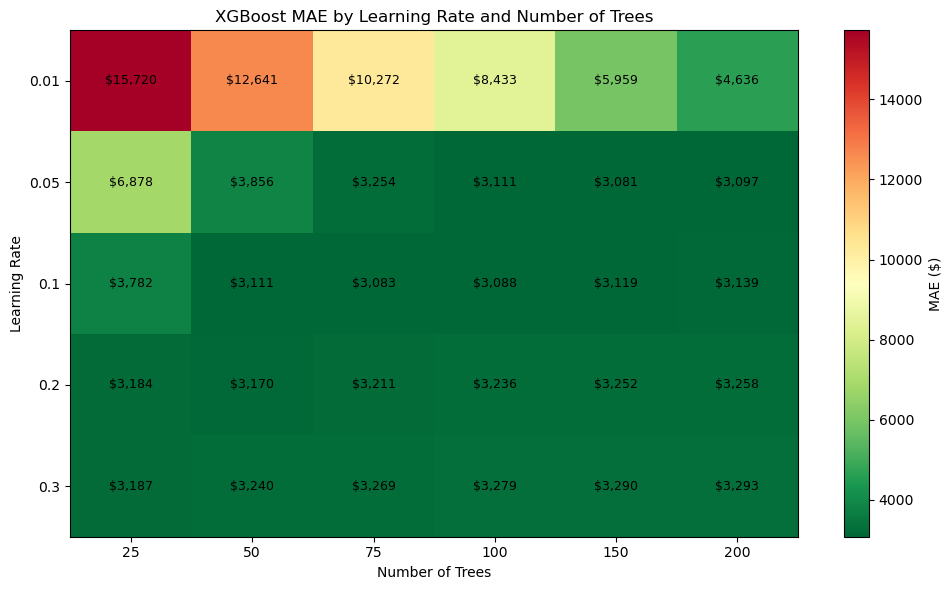

Best combination: learning_rate=0.05, n_estimators=150, MAE=$3,081.14


In [10]:
# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(results, cmap="RdYlGn_r", aspect="auto")

ax.set_xticks(range(len(n_estimators_range)))
ax.set_xticklabels(n_estimators_range)
ax.set_yticks(range(len(learning_rates)))
ax.set_yticklabels(learning_rates)
ax.set_xlabel("Number of Trees")
ax.set_ylabel("Learning Rate")
ax.set_title("XGBoost MAE by Learning Rate and Number of Trees")

# Add values to cells
for i in range(len(learning_rates)):
    for j in range(len(n_estimators_range)):
        ax.text(j, i, f"${results[i,j]:,.0f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, label="MAE ($)")
plt.tight_layout()
plt.show()

# Find best combination
best_idx = np.unravel_index(results.argmin(), results.shape)
best_lr = learning_rates[best_idx[0]]
best_n = n_estimators_range[best_idx[1]]
print(f"Best combination: learning_rate={best_lr}, n_estimators={best_n}, MAE=${results.min():,.2f}")

## XGBoost with Tuned Parameters

In [13]:
# ============================================================
# EXERCISE: Fill in the best parameters from the heatmap
# ============================================================
model_tuned = xgb.XGBRegressor(n_estimators=75, learning_rate=0.1, random_state=42)

scores_tuned = cross_val_score(model_tuned, X, y, cv=5, scoring="neg_mean_absolute_error")
pred_tuned = cross_val_predict(model_tuned, X, y, cv=5)

print(f"Tuned XGBoost — MAE = ${-scores_tuned.mean():,.2f} (±${scores_tuned.std():,.2f})")

Tuned XGBoost — MAE = $3,082.80 (±$394.38)


## Comparison: Default vs Tuned

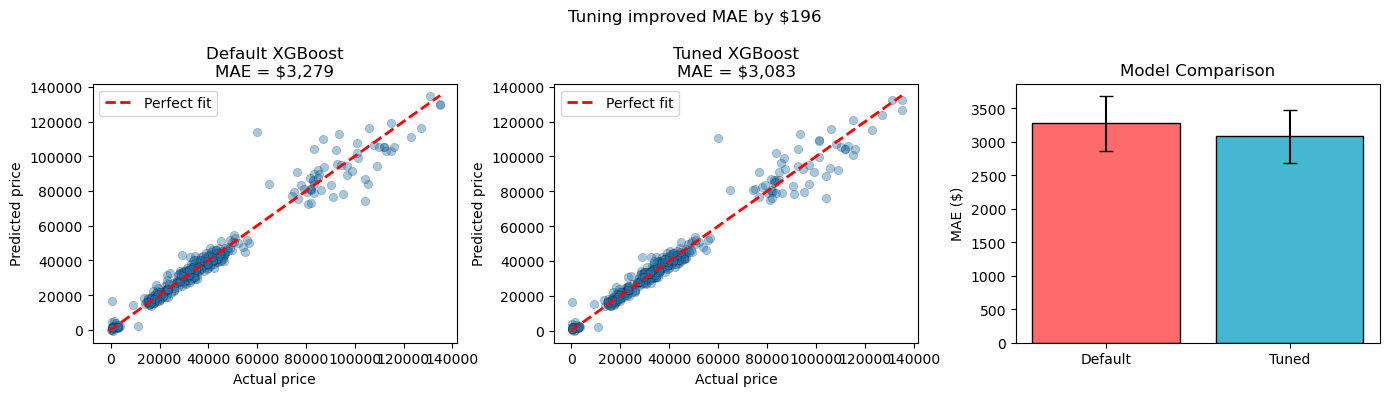

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, pred) in zip(axes[:2], [("Default XGBoost", pred_default), ("Tuned XGBoost", pred_tuned)]):
    mae = mean_absolute_error(y, pred)
    ax.scatter(y, pred, alpha=0.4, edgecolor="k", linewidth=0.3)
    lims = [min(y.min(), pred.min()), max(y.max(), pred.max())]
    ax.plot(lims, lims, "r--", linewidth=2, label="Perfect fit")
    ax.set_xlabel("Actual price")
    ax.set_ylabel("Predicted price")
    ax.set_title(f"{name}\nMAE = ${mae:,.0f}")
    ax.legend()

# Bar plot
maes = [-scores_default.mean(), -scores_tuned.mean()]
stds = [scores_default.std(), scores_tuned.std()]
axes[2].bar(["Default", "Tuned"], maes, yerr=stds, color=["#ff6b6b", "#45b7d1"], edgecolor="k", capsize=5)
axes[2].set_ylabel("MAE ($)")
axes[2].set_title("Model Comparison")

improvement = -scores_default.mean() - (-scores_tuned.mean())
fig.suptitle(f"Tuning improved MAE by ${improvement:,.0f}", fontsize=12)
plt.tight_layout()
plt.show()

## Feature Importance

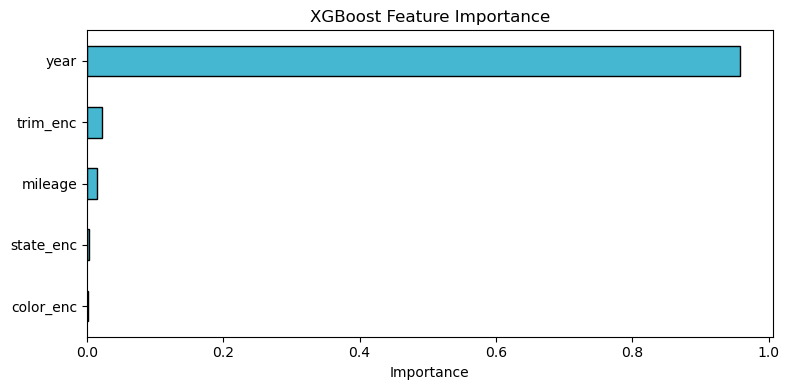

Feature importance (descending):
  year: 95.9%
  trim_enc: 2.2%
  mileage: 1.5%
  state_enc: 0.2%
  color_enc: 0.2%


In [25]:
# Fit tuned model on full data for feature importance
model_tuned.fit(X, y)

importance = pd.Series(model_tuned.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind="barh", ax=ax, color="#45b7d1", edgecolor="k")
ax.set_xlabel("Importance")
ax.set_title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

print("Feature importance (descending):")
for feat, imp in importance.sort_values(ascending=False).items():
    print(f"  {feat}: {imp:.1%}")

---
## Questions

### Question 1: Learning Rate and Number of Trees

**Q1a:** Look at the heatmap. Describe the relationship between learning rate and optimal number of trees. Why does a lower learning rate need more trees?

*Your answer:*



**Q1b:** What happens when you use a high learning rate (e.g., 0.3) with too many trees? Why?

*Your answer:*



---
### Question 2: Is Tuning Worth It?

**Q2:** Compare the MAE improvement from tuning vs the default model. In what business situations would this improvement justify the extra effort of tuning? When might you just use the defaults?

*Your answer:*



---
### Question 3: Feature Importance

**Q3a:** Year dominates feature importance (~90%+). Does this mean mileage doesn't matter for pricing, or is something else going on? (Hint: think about correlation between features)

*Your answer:*



**Q3b:** A dealership manager says "the model shows color doesn't affect price, so let's stop tracking it." Do you agree? What's the risk of dropping low-importance features?

*Your answer:*



---
### Question 4: Pricing Edge Cases

**Q4:** Look at the scatter plot of actual vs predicted prices. The model struggles more with certain vehicles (points far from the red line). What types of vehicles do you think are hardest to price accurately, and how should a dealership handle these cases?

*Your answer:*



---
### Question 5: Deploying the Model

**Q5:** You're recommending this model to a dealership. The owner asks: "How often should we retrain this model?" What factors would cause the model's accuracy to degrade over time, and what would trigger a need to retrain?

*Your answer:*

